# Preprocessing: Daylight-Driven Indoor Farming Dataset

This notebook preprocesses the combined simulation dataset for training **GHR** and **DLI** prediction models.

**Steps:**
1. Load & inspect data
2. Handle missing values & data types
3. Encode categorical features
4. Feature engineering (cyclical day encoding, interaction features)
5. Train/test split (stratified by season)
6. Feature scaling
7. Export train/test sets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
print("Libraries loaded.")

Note: you may need to restart the kernel to use updated packages.


Libraries loaded.


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv("../datasets/combined_dataset.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (87600, 12)


,Day_of_Year,Season,Tree_Width_m,Tree_Present,Window_Transmittance,Building,Orientation,Level,Facade,WWR,GHR,DLI
0,1,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,81.657165,0.593207
1,2,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,86.781723,0.630435
2,3,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,86.673542,0.629649
3,4,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,72.861989,0.529313
4,5,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,86.143462,0.625798
5,6,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,78.870061,0.572959
6,7,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,89.230604,0.648225
7,8,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,77.596763,0.563709
8,9,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,77.155449,0.560503
9,10,Winter,3,False,0.1,Architecture,E,G,E_G_Architecture,0.349091,85.793877,0.623258


### Note on DLI and GHR relationship

DLI = GHR × 0.00726460 (exact constant ratio from simulation). We only train a model for GHR; DLI is derived by multiplication.

In [3]:
print("--- Data Types ---")
print(df.dtypes)
print(f"\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\n--- Basic Statistics ---")
df.describe()

--- Data Types ---
Day_of_Year               int64
Season                   object
Tree_Width_m              int64
Tree_Present               bool
Window_Transmittance    float64
Building                 object
Orientation              object
Level                    object
Facade                   object
WWR                     float64
GHR                     float64
DLI                     float64
dtype: object

--- Missing Values ---
Day_of_Year             0
Season                  0
Tree_Width_m            0
Tree_Present            0
Window_Transmittance    0
Building                0
Orientation             0
Level                   0
Facade                  0
WWR                     0
GHR                     0
DLI                     0
dtype: int64

--- Basic Statistics ---


,Day_of_Year,Tree_Width_m,Window_Transmittance,WWR,GHR,DLI
count,87600.00000,87600.000000,87600.000000,87600.000000,87600.000000,87600.000000
mean,183.00000,4.500000,0.533333,0.347069,703.655040,5.111772
std,105.36663,1.500009,0.329985,0.114296,986.150994,7.163993
min,1.00000,3.000000,0.100000,0.111111,12.175034,0.088447
25%,92.00000,3.000000,0.100000,0.261818,157.662534,1.145355
50%,183.00000,4.500000,0.600000,0.349091,342.318700,2.486808
75%,274.00000,6.000000,0.900000,0.443182,737.162542,5.355191
max,365.00000,6.000000,0.900000,0.500000,7011.598149,50.936456


In [4]:
print("--- Unique Values per Categorical Column ---")
cat_cols = ["Season", "Tree_Width_m", "Tree_Present", "Window_Transmittance",
            "Orientation", "Level"]
for col in cat_cols:
    print(f"  {col}: {df[col].unique()}")

--- Unique Values per Categorical Column ---
  Season: ['Winter' 'Spring' 'Summer' 'Autumn']
  Tree_Width_m: [3 6]
  Tree_Present: [False  True]
  Window_Transmittance: [0.1 0.6 0.9]
  Orientation: ['E' 'N' 'W' 'NE' 'NW' 'SE' 'S']
  Level: ['G' 'U' 'M']


## 2. Target Distribution

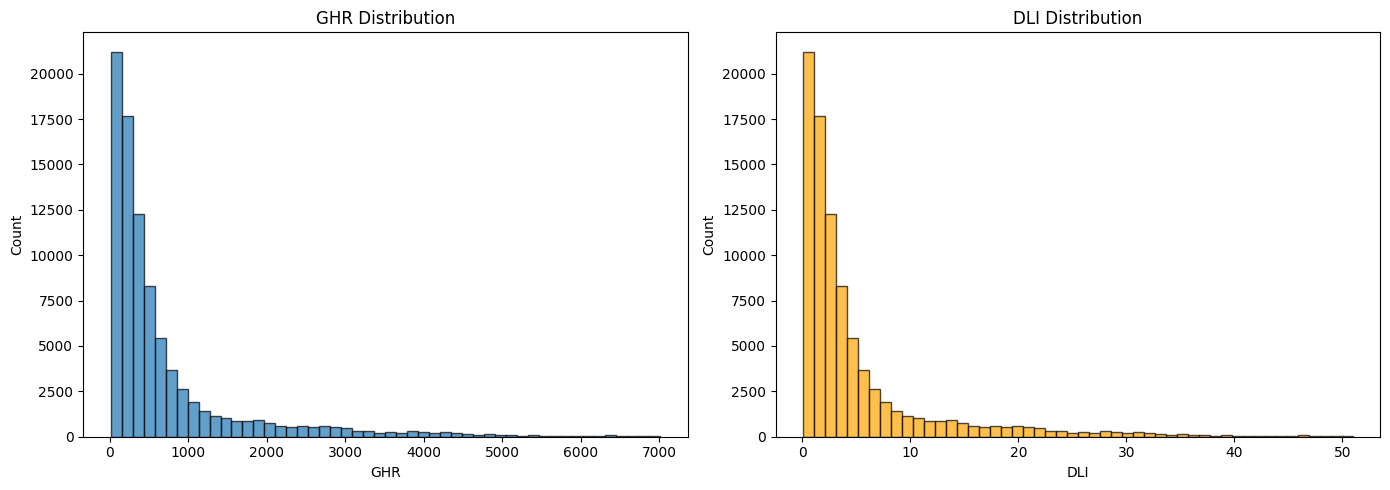

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["GHR"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("GHR Distribution")
axes[0].set_xlabel("GHR")
axes[0].set_ylabel("Count")

axes[1].hist(df["DLI"], bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_title("DLI Distribution")
axes[1].set_xlabel("DLI")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

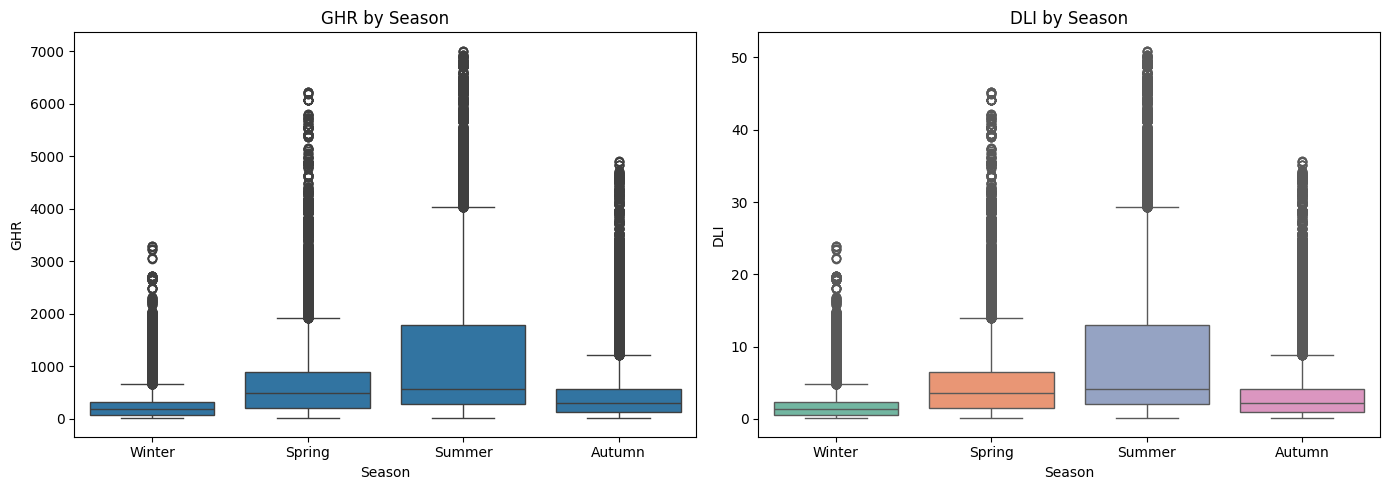

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_order = ["Winter", "Spring", "Summer", "Autumn"]
df_plot = df.copy()
df_plot["Season"] = pd.Categorical(df_plot["Season"], categories=season_order, ordered=True)

sns.boxplot(data=df_plot, x="Season", y="GHR", ax=axes[0], order=season_order)
axes[0].set_title("GHR by Season")

sns.boxplot(data=df_plot, x="Season", y="DLI", ax=axes[1], order=season_order, palette="Set2")
axes[1].set_title("DLI by Season")

plt.tight_layout()
plt.show()

## 3. Encode Categorical Features

- **Season**: Encoded as cyclical (sin/cos) to preserve continuity (Winter <-> Autumn)
- **Orientation, Level**: Label encoded (will also create one-hot version)
- **Tree_Present**: Already boolean -> convert to int
- **Building**: Excluded as a feature (model generalizes via building properties like WWR, Orientation, Level)

In [7]:
df_proc = df.copy()

# --- Boolean to int ---
df_proc["Tree_Present"] = df_proc["Tree_Present"].astype(int)

# --- Cyclical encoding for Day_of_Year ---
df_proc["Day_sin"] = np.sin(2 * np.pi * df_proc["Day_of_Year"] / 365)
df_proc["Day_cos"] = np.cos(2 * np.pi * df_proc["Day_of_Year"] / 365)

# --- Season cyclical encoding ---
season_map = {"Winter": 0, "Spring": 1, "Summer": 2, "Autumn": 3}
df_proc["Season_num"] = df_proc["Season"].map(season_map)
df_proc["Season_sin"] = np.sin(2 * np.pi * df_proc["Season_num"] / 4)
df_proc["Season_cos"] = np.cos(2 * np.pi * df_proc["Season_num"] / 4)

# --- Label encode categoricals ---
# Note: Building is excluded — the model should generalize to new buildings
# using building *properties* (WWR, Orientation, Level, Window_Transmittance, Tree params)
# rather than building *identity*.
label_encoders = {}
for col in ["Orientation", "Level"]:
    le = LabelEncoder()
    df_proc[f"{col}_enc"] = le.fit_transform(df_proc[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# --- One-hot encode for tree-based models ---
df_proc = pd.get_dummies(df_proc, columns=["Orientation", "Level"], 
                          prefix=["Ori", "Lvl"], dtype=int)

print(f"\nShape after encoding: {df_proc.shape}")
df_proc.head(3)

Orientation: {'E': np.int64(0), 'N': np.int64(1), 'NE': np.int64(2), 'NW': np.int64(3), 'S': np.int64(4), 'SE': np.int64(5), 'W': np.int64(6)}
Level: {'G': np.int64(0), 'M': np.int64(1), 'U': np.int64(2)}

Shape after encoding: (87600, 27)


,Day_of_Year,Season,Tree_Width_m,Tree_Present,Window_Transmittance,Building,Facade,WWR,GHR,DLI,Day_sin,Day_cos,Season_num,Season_sin,Season_cos,Orientation_enc,Level_enc,Ori_E,Ori_N,Ori_NE,Ori_NW,Ori_S,Ori_SE,Ori_W,Lvl_G,Lvl_M,Lvl_U
0,1,Winter,3,0,0.1,Architecture,E_G_Architecture,0.349091,81.657165,0.593207,0.017213,0.999852,0,0.0,1.0,0,0,1,0,0,0,0,0,0,1,0,0
1,2,Winter,3,0,0.1,Architecture,E_G_Architecture,0.349091,86.781723,0.630435,0.034422,0.999407,0,0.0,1.0,0,0,1,0,0,0,0,0,0,1,0,0
2,3,Winter,3,0,0.1,Architecture,E_G_Architecture,0.349091,86.673542,0.629649,0.051620,0.998667,0,0.0,1.0,0,0,1,0,0,0,0,0,0,1,0,0


## 4. Feature Engineering

In [8]:
# --- Interaction features ---
# Effective transmittance considering tree obstruction
df_proc["Effective_Transmittance"] = df_proc["Window_Transmittance"] * (1 - df_proc["Tree_Present"] * 0.9)

# WWR x Transmittance interaction
df_proc["WWR_x_Transmittance"] = df_proc["WWR"] * df_proc["Window_Transmittance"]

# Tree effect (width * presence)
df_proc["Tree_Effect"] = df_proc["Tree_Width_m"] * df_proc["Tree_Present"]

print("New features added:")
print(f"  Effective_Transmittance: {df_proc['Effective_Transmittance'].describe().to_dict()}")
print(f"  WWR_x_Transmittance:    {df_proc['WWR_x_Transmittance'].describe().to_dict()}")
print(f"  Tree_Effect:             {df_proc['Tree_Effect'].describe().to_dict()}")

New features added:
  Effective_Transmittance: {'count': 87600.0, 'mean': 0.29333333333333333, 'std': 0.33554459340726933, 'min': 0.009999999999999998, '25%': 0.059999999999999984, '50%': 0.095, '75%': 0.6, 'max': 0.9}
  WWR_x_Transmittance:    {'count': 87600.0, 'mean': 0.18510344827586206, 'std': 0.13511058499502204, 'min': 0.011111111111111112, '25%': 0.04431818181818182, '50%': 0.1785454545454545, '75%': 0.3, 'max': 0.45}
  Tree_Effect:             {'count': 87600.0, 'mean': 2.25, 'std': 2.4874827907682038, 'min': 0.0, '25%': 0.0, '50%': 1.5, '75%': 3.75, 'max': 6.0}


## 5. Correlation Analysis

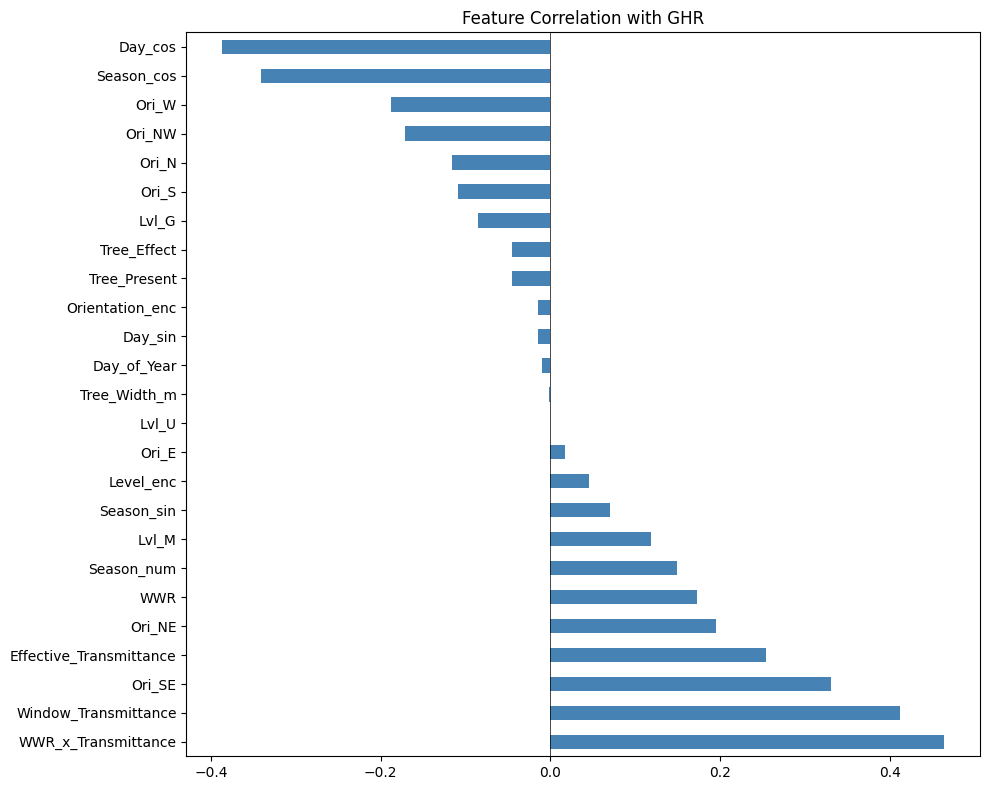

In [9]:
# Correlation of numeric features with GHR (DLI is just GHR × constant, so identical correlation)
numeric_cols = df_proc.select_dtypes(include=[np.number]).columns
corr_ghr = df_proc[numeric_cols].corr()["GHR"].drop(["GHR", "DLI"]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

corr_ghr.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Correlation with GHR")
ax.axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

## 6. Define Feature Sets & Split Data

We prepare two feature sets:
- **For neural networks / linear models**: uses label-encoded categoricals + scaled numerics
- **For tree-based models (XGBoost, RF)**: uses one-hot encoded categoricals, no scaling needed

Split: 80% train / 20% test, stratified by Season to preserve seasonal balance.

In [10]:
# --- Drop non-feature columns ---
drop_cols = ["Season", "Building", "Facade", "Season_num", "GHR", "DLI"]
targets = df_proc[["GHR"]]

# Constant ratio: DLI = GHR * DLI_RATIO
DLI_RATIO = 0.00726460

# Feature set for tree-based models (one-hot, no scaling)
features_tree = df_proc.drop(columns=drop_cols)
# Also drop label-encoded versions for tree models (redundant with one-hot)
features_tree = features_tree.drop(columns=["Orientation_enc", "Level_enc"])

# Feature set for neural nets (label-encoded, will be scaled)
ohe_cols = [c for c in df_proc.columns if c.startswith(("Ori_", "Lvl_"))]
features_nn = df_proc.drop(columns=drop_cols + ohe_cols)

print(f"Tree-based feature set: {features_tree.shape[1]} features")
print(f"  Columns: {list(features_tree.columns)}")
print(f"\nNeural net feature set: {features_nn.shape[1]} features")
print(f"  Columns: {list(features_nn.columns)}")
print(f"\nTarget: GHR only (DLI = GHR × {DLI_RATIO})")

Tree-based feature set: 22 features
  Columns: ['Day_of_Year', 'Tree_Width_m', 'Tree_Present', 'Window_Transmittance', 'WWR', 'Day_sin', 'Day_cos', 'Season_sin', 'Season_cos', 'Ori_E', 'Ori_N', 'Ori_NE', 'Ori_NW', 'Ori_S', 'Ori_SE', 'Ori_W', 'Lvl_G', 'Lvl_M', 'Lvl_U', 'Effective_Transmittance', 'WWR_x_Transmittance', 'Tree_Effect']

Neural net feature set: 14 features
  Columns: ['Day_of_Year', 'Tree_Width_m', 'Tree_Present', 'Window_Transmittance', 'WWR', 'Day_sin', 'Day_cos', 'Season_sin', 'Season_cos', 'Orientation_enc', 'Level_enc', 'Effective_Transmittance', 'WWR_x_Transmittance', 'Tree_Effect']

Target: GHR only (DLI = GHR × 0.0072646)


In [11]:
# --- Stratified train/test split ---
stratify_col = df_proc["Season"].map(season_map)  # use season for stratification

X_train_tree, X_test_tree, y_train, y_test = train_test_split(
    features_tree, targets, test_size=0.2, random_state=42, stratify=stratify_col
)

X_train_nn, X_test_nn, _, _ = train_test_split(
    features_nn, targets, test_size=0.2, random_state=42, stratify=stratify_col
)

print(f"Train: {X_train_tree.shape[0]} samples")
print(f"Test:  {X_test_tree.shape[0]} samples")

# Verify season balance
train_seasons = df.loc[y_train.index, "Season"].value_counts(normalize=True)
test_seasons = df.loc[y_test.index, "Season"].value_counts(normalize=True)
print(f"\nSeason distribution (train vs test):")
for s in season_order:
    print(f"  {s}: train={train_seasons.get(s, 0):.3f}  test={test_seasons.get(s, 0):.3f}")

Train: 70080 samples
Test:  17520 samples

Season distribution (train vs test):
  Winter: train=0.247  test=0.247
  Spring: train=0.252  test=0.252
  Summer: train=0.252  test=0.252
  Autumn: train=0.249  test=0.249


## 7. Feature Scaling (for Neural Net feature set)

In [12]:
# Scale features (fit on train only)
scaler_X = StandardScaler()
X_train_nn_scaled = pd.DataFrame(
    scaler_X.fit_transform(X_train_nn), columns=X_train_nn.columns, index=X_train_nn.index
)
X_test_nn_scaled = pd.DataFrame(
    scaler_X.transform(X_test_nn), columns=X_test_nn.columns, index=X_test_nn.index
)

# Scale target (GHR only) for neural nets
scaler_y = StandardScaler()
y_train_scaled = pd.DataFrame(
    scaler_y.fit_transform(y_train), columns=y_train.columns, index=y_train.index
)
y_test_scaled = pd.DataFrame(
    scaler_y.transform(y_test), columns=y_test.columns, index=y_test.index
)

print("Scaled feature stats (train):")
print(X_train_nn_scaled.describe().loc[["mean", "std"]].round(3))
print(f"\nTarget scaler params: mean={scaler_y.mean_}, scale={scaler_y.scale_}")

Scaled feature stats (train):


      Day_of_Year  Tree_Width_m  Tree_Present  Window_Transmittance  WWR  \
mean         -0.0          -0.0          -0.0                  -0.0 -0.0   
std           1.0           1.0           1.0                   1.0  1.0   

      Day_sin  Day_cos  Season_sin  Season_cos  Orientation_enc  Level_enc  \
mean     -0.0      0.0         0.0        -0.0              0.0        0.0   
std       1.0      1.0         1.0         1.0              1.0        1.0   

      Effective_Transmittance  WWR_x_Transmittance  Tree_Effect  
mean                     -0.0                 -0.0         -0.0  
std                       1.0                  1.0          1.0  

Target scaler params: mean=[704.0435349], scale=[984.65491423]


## 8. Export Processed Data

In [13]:
import os
import json
import joblib

output_dir = "../datasets/processed"
os.makedirs(output_dir, exist_ok=True)

# Tree-based model data (unscaled)
X_train_tree.to_csv(f"{output_dir}/X_train_tree.csv", index=False)
X_test_tree.to_csv(f"{output_dir}/X_test_tree.csv", index=False)

# Neural net data (scaled)
X_train_nn_scaled.to_csv(f"{output_dir}/X_train_nn.csv", index=False)
X_test_nn_scaled.to_csv(f"{output_dir}/X_test_nn.csv", index=False)

# Targets (GHR only)
y_train.to_csv(f"{output_dir}/y_train.csv", index=False)
y_test.to_csv(f"{output_dir}/y_test.csv", index=False)
y_train_scaled.to_csv(f"{output_dir}/y_train_scaled.csv", index=False)
y_test_scaled.to_csv(f"{output_dir}/y_test_scaled.csv", index=False)

# Scalers (for inverse transform during inference)
joblib.dump(scaler_X, f"{output_dir}/scaler_X.pkl")
joblib.dump(scaler_y, f"{output_dir}/scaler_y.pkl")

# Label encoders
joblib.dump(label_encoders, f"{output_dir}/label_encoders.pkl")

# DLI ratio constant
with open(f"{output_dir}/dli_ratio.json", "w") as f:
    json.dump({"DLI_RATIO": DLI_RATIO, "description": "DLI = GHR * DLI_RATIO"}, f, indent=2)

print("Exported files:")
for f in sorted(os.listdir(output_dir)):
    size = os.path.getsize(f"{output_dir}/{f}") / 1024
    print(f"  {f:30s} {size:8.1f} KB")

Exported files:
  X_test_nn.csv                    4723.1 KB
  X_test_tree.csv                  2434.0 KB
  X_train_nn.csv                  18894.1 KB
  X_train_tree.csv                 9719.9 KB
  dli_ratio.json                      0.1 KB
  label_encoders.pkl                  0.7 KB
  scaler_X.pkl                        1.4 KB
  scaler_y.pkl                        0.9 KB
  y_test.csv                        186.6 KB
  y_test_scaled.csv                 341.1 KB
  y_train.csv                       747.1 KB
  y_train_scaled.csv               1365.2 KB


## 9. Summary

| Item | Detail |
|------|--------|
| Total samples | 87,600 |
| Train / Test | 80% / 20% (stratified by season) |
| Target | `GHR` only (single target) |
| DLI derivation | `DLI = GHR * 0.00726460` (exact constant, saved in `dli_ratio.json`) |
| Tree-based features | One-hot encoded categoricals, raw numerics |
| Neural net features | Label-encoded categoricals, StandardScaler applied |
| Cyclical features | `Day_sin`, `Day_cos`, `Season_sin`, `Season_cos` |
| Interaction features | `Effective_Transmittance`, `WWR_x_Transmittance`, `Tree_Effect` |

**Next step**: Use the exported CSVs in `datasets/processed/` to train the GHR prediction model. DLI predictions are obtained by multiplying GHR predictions by the constant ratio.